<a href="https://colab.research.google.com/github/mnilsson8/Cube/blob/main/CheckingICanUsePresto2Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# from google.colab import drive

# drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
# cd /content/gdrive/MyDrive/PrestoColor2/

/content/gdrive/.shortcut-targets-by-id/1bo5dF0afSpNZR426-ydBpvRIXBEuLPPi/PrestoColor2


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import Functions

from astropy.io import fits
from astropy.table import Table
from collections import OrderedDict as odict
import time
import math
from scipy import interpolate
import pickle

In [4]:
# Path = '/content/gdrive/MyDrive/PrestoColor2/GSN_IDEAL_z02'
Path = '/lustre/lrspec/prestocolor/GSN_IDEAL_z02'

In [5]:
data = Functions.ReadData(Path, 'SNIa-SALT2', 0, 0)

In [6]:
data

MJD,BAND,CCDNUM,FIELD,PHOTFLAG,PHOTPROB,FLUXCAL,FLUXCALERR,PSF_SIG1,PSF_SIG2,PSF_RATIO,SKY_SIG,SKY_SIG_T,RDNOISE,ZEROPT,ZEROPT_ERR,GAIN,SIM_MAGOBS,SIM_FLUXCAL_HOSTERR
float64,bytes2,int16,bytes12,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
53000.0,u,-9,NULL,0,-9.0,-0.0061405096,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53000.0,g,-9,NULL,0,-9.0,0.0036151197,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53000.0,r,-9,NULL,0,-9.0,-0.0020213476,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53000.0,i,-9,NULL,0,-9.0,0.0032451483,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53000.0,z,-9,NULL,0,-9.0,0.0051861512,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53000.0,Y,-9,NULL,0,-9.0,0.0036822045,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53002.0,u,-9,NULL,0,-9.0,-0.0036757744,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53002.0,g,-9,NULL,0,-9.0,0.0011087777,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0
53002.0,r,-9,NULL,0,-9.0,-0.004769873,nan,1.0,0.0,0.0,1264.911,0.0,31.622776,42.5,0.0,1.0,99.0,0.0


In [7]:
#I want to test the code I wrote for the SweetSpot data and see how it does (it admittedly might be too slow, but it's a way of finding delta ts without interpolating)
#okay yeah interpolating is probably the right answer bt what do I care about being right
#I could interpolate the Sweetspot data (all 2 or three data points lol)
#okay well the immediate next step is interpolating the data and plotting light curves

In [8]:
PathsDict = Functions.GetEventPaths(Path)
EventNames = list(PathsDict.keys())

Functions.GetEventPaths():
def GetEventPaths(Path):

    PathsDict = {}
    FolderNames = os.listdir(Path)

    for FolderName in FolderNames:
        Ind = FolderName.find('MODEL')
        if Ind > -1:
            EventName = FolderName[Ind+8:]
            PathsDict[EventName] = os.path.join(Path, FolderName)
    return dict(sorted(PathsDict.items()))

It looks for the word "model" in the folder name and then takes whatever comes after 8 characters after the start of the word "MODEL" as the name of the event. Then it adds it to a dictionary.
This is going to have have to be changed if I'm trying to genericize the functions, especialy if the point is it's all Type-Ia SNe.

In [9]:
#parameter setting
EventNames = EventNames

Bands = ['u ', 'g ', 'r ', 'i ', 'z ', 'Y ']

StartFile = 0
EndFile = None

StartObject = 0
EndObject = None

In [10]:
# for EventName in EventNames:
# only doing it for SNe Ia, so commenting out the above and replacing every instance of EventName with "SNIa-SALT2"

print('Processing {:<25}'.format("SNIa-SALT2"+':'), end='')
start = time.time()

SNIaFits = {'u': [], 'g': [], 'r': [], 'i': [], 'z': [], 'Y': []}

EventPath = PathsDict["SNIa-SALT2"]
FileNames = os.listdir(EventPath)
FileNames.sort()

for FileName in FileNames[StartFile: EndFile]:

    Ind = FileName.find('HEAD')

    if Ind > -1:

        print('|', end='')

        FileNamePHOT = FileName[:Ind] + 'PHOT.FITS.gz'

        HeadFilePath = os.path.join(EventPath, FileName)
        PhotFilePath = os.path.join(EventPath, FileNamePHOT)
        Data = Functions.read_snana_fits(HeadFilePath, PhotFilePath)

        # note that there is a header file and a photometry file from the Snana simulations, so that's something I need to take into account when trying
        # generalize my code

        for II, Obj in enumerate(Data[StartObject: EndObject]):

            for Band in Bands:

                Mask = Obj['BAND']==Band

                #THIS IS WHERE INTERPOLATION HAPPENS
                fobject  = interpolate.interp1d(Obj['MJD'][Mask], Obj['SIM_MAGOBS'][Mask])
                #interp1d legacy function, replace with different 1d interpolator
                #don't know which one, good question to ask "I noticed that scipy.interpolate.interp1d is a legacy function now,
                #is there a particular interpolation function I should use?"
                SNIaFits[Band[0]].append(fobject)

TimeRange = [Obj['MJD'][Mask][0], Obj['MJD'][Mask][-1]]

# with open(EventName+'_Fit.pkl', 'wb') as f:
#     pickle.dump(SNIaFits, f)
#     pickle.dump(TimeRange, f )
# something I need to look into

end = time.time()
print('\t time spent: {0:6.3f} s'.format(end-start))


Processing SNIa-SALT2:              ||||||||||||||||||||	 time spent: 65.598 s


In [11]:
SNIaFits["u"][1]

Text(0, 0.5, 'Obs Mag')

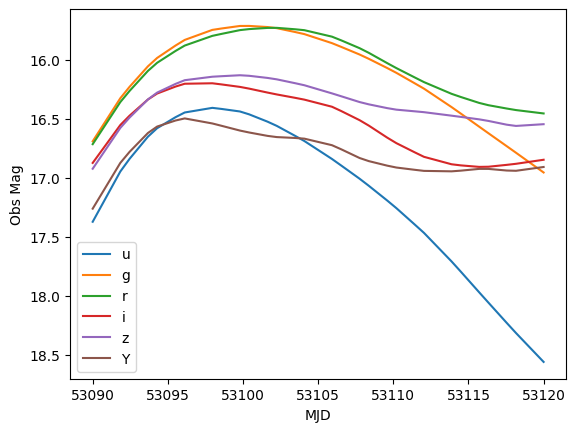

In [ ]:
XX = np.linspace(53090, 53120)
for i in Bands:
  plt.plot(XX, SNIaFits[i.replace(" ","")][1](XX), label = i.replace(" ",""))
plt.gca().invert_yaxis()
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Obs Mag")


Plot of 1 simulated SNIa in all 6 bands. This shows that I can use the PrestoColor 2 data and it mostly makes sense to me. The next step is making  and plotting some data cube slices from this data.